# Link Budget

$\Rightarrow$ [Jump to Linkbudget Simulation](#link-budget-simulation)

---

## Theoretical Background

By calculating the link budget of the telemetry system, either the maximum range of the system or individual parameters, such as transmit power, can be determined at a fixed range. A detailed explanation of the link budget can be found [here](https://s.campbellsci.com/documents/us/technical-papers/link-budget.pdf). Additional informations are available [here](https://en.wikipedia.org/wiki/Link_budget) and [here](https://www.sss-mag.com/pdf/an9804.pdf).

The general formula for a link budget describes the signal strength at the receiver and includes components that either increase (positive sign) or decrease (negative sign) the received strength. All values are given in dB (or dBm and dBi).

$P_\mathrm{RX} = P_\mathrm{TX} + G_\mathrm{TX} - L_\mathrm{TX} - L_\mathrm{FS} - L_\mathrm{M} + G_\mathrm{RX} - L_\mathrm{RX}$

### Transmitter Parameters:
- Transmit Power $P_\mathrm{TX}$ 
Specified in the data sheet of the radio module: $P_\mathrm{TX} = 27$ dBm
- Gain of the Transmitting Antenna $G_\mathrm{TX}$ 
Depending on the selected transmitting antenna (QFH, dipole, ...)
- Transmission Losses on the Transmitting Side $L_\mathrm{TX}$ 
Includes losses in cables and traces as well as transition losses at connectors or other components. These losses depend on the coaxial cable used, the connectors, and much more, and can only be estimated or measured: $L_\mathrm{TX} < 5$ dB

### Receiver Parameters:
- Signal Strength at the Receiver $P_\mathrm{RX}$ 
The minimum signal strength of the radio module is specified in the data sheet: $P_\mathrm{RX, typ} = -118$ dBm, $P_\mathrm{RX, min} = -114$ dBm
- Gain of the Receiving Antenna $G_\mathrm{RX}$ 
Depending on the selected receiving antenna (Helical, dipole, patch, ...)
- Transmission Losses on the Receiving Side $L_\mathrm{RX}$ 
See $L_\mathrm{TX}$: $L_\mathrm{RX} < 5$ dB

### Path Loss:
- Free Space Attenuation $L_\mathrm{FS}$ 
The free space attenuation describes the reduced power density of an EM wave as the distance from the source increases. The formula is: $L_\mathrm{FS} = 20 \cdot \mathrm{log}\left(\frac{4 \pi r f}{c}\right)$ (with $r$ as the distance to the transmitting antenna and $f$ as the frequency used). At a range of $10$ km this yields $L_\mathrm{FS} \approx 111$ dB for 860 MHz and $L_\mathrm{FS} \approx 97$ dB for 169 MHz.
- Additional Losses During Propagation $L_\mathrm{M}$ 
These losses include absorption losses in the atmosphere, losses due to diffraction and shadowing, as well as losses due to diffraction at obstacles within the Fresnel zone (potentially occurring as fading). They are difficult to estimate and can only be verified through measurements.

Reflection effects can potentially be calculated and included as described [here](https://s.campbellsci.com/documents/us/technical-papers/link-budget.pdf) in Chapter 5.3. These likely have no effect in our case due to the height of the antennas.

### Link Margin:

The formula for the link budget can be rearranged to calculate the maximum tolerable losses due to transmission for the maximum desired range. $L_\mathrm{TX} + L_\mathrm{RX} + L_\mathrm{M}$ are the unknown losses here.

$L_\mathrm{TX} + L_\mathrm{RX} + L_\mathrm{M} = P_\mathrm{TX} - P_\mathrm{RX} + G_\mathrm{TX} + G_\mathrm{RX} - L_\mathrm{FS}$

The actual values for $L_\mathrm{TX}$ and $L_\mathrm{RX}$ can be determined through measurements, and the entire formula can be validated and adjusted step by step. If $L_\mathrm{TX}$ and $L_\mathrm{RX}$ are either estimated concretely or measured, only $L_\mathrm{M}$ remains.

$L_\mathrm{M}$ can be understood as a sort of safety buffer (link margin) for adverse atmospheric conditions, poor estimates, or measurements of other parameters and guarantees a reliable connection. This buffer should never be smaller than $10$ dB and should be greater than $20$ dB or $30$ dB for reliable connections.

If the link margin is too small, the received signal can be amplified using a stronger directional reception antenna or by incorporating an amplifier. If the link margin is comparatively large, for example, the data rate can be increased or the directivity of the receiving antenna can be reduced.

### Range Calculation:

If $L_\mathrm{M}$ is specified, the formula can be arranged to calculate the maximum distance.

$r = \frac{c}{4 \pi f}10^\frac{P_\mathrm{TX} - P_\mathrm{RX} + G_\mathrm{TX} + G_\mathrm{RX} - L_\mathrm{TX} - L_\mathrm{RX} - L_\mathrm{M}}{20}$

For the application for the European Rocketry Challenge (EuRoC), we used the following values:

$P_\mathrm{TX} = 27$ dBm<br>
$P_\mathrm{RX} = -114$ dBm<br>
$G_\mathrm{TX} = -5$ dBi<br>
$G_\mathrm{RX,869} = 16.5$ dBi, $G_\mathrm{RX,169} = 0$ dBi<br>
$L_\mathrm{TX} = 3$ dB<br>
$L_\mathrm{RX} = 3$ dB<br>
$L_\mathrm{M} = 30$ dB

The calculated ranges are: <br>
$r_\mathrm{869} \approx 18.4$ km<br>
$r_\mathrm{169} \approx 14.1$ km<br>

---

## Link Budget Simulation

### Link Margin Calculation Function

$L_\mathrm{M} = P_\mathrm{TX} - P_\mathrm{RX} + G_\mathrm{TX} + G_\mathrm{RX} - L_\mathrm{TX} - L_\mathrm{RX} - L_\mathrm{FS}$

In [1]:
import matplotlib.pyplot as plt
import numpy as np

def LinkMargin(f, r, P_TX, G_TX, L_TX, P_RX, G_RX, L_RX):

    L_FS = 20 * np.log10((4 * np.pi * r * f)/(2.998e+8))                    # Free Space Attenuation
    L_M = P_TX - P_RX + G_TX + G_RX - L_FS - L_TX - L_RX                    # Link Margin
    return L_M

### Calculation for the 869 MHz System

Text(0.5, 1.0, '869 MHz (RC1780HP-RC232)')

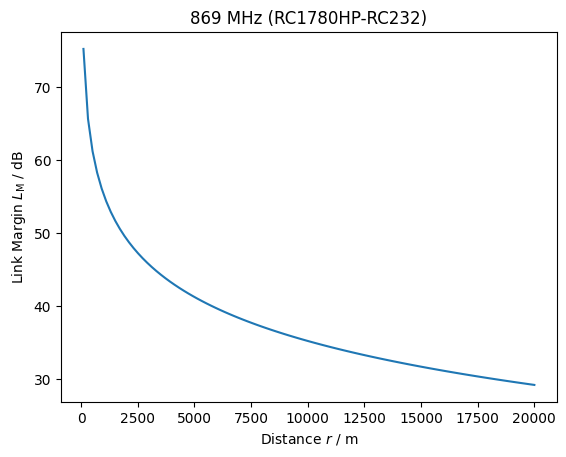

In [2]:
f = 869.525e+6                              # 869.525 MHz radio frequency

P_TX = 27                                   # Transmit signal strength RC1780HP-RC232
G_TX = -5                                   # QFH-antenna gain (estimated, in reality dependant on the angle)
L_TX = 3                                    # Transmit (cable, ...) losses (estimation)

P_RX = -114                                 # Minimum receive signal strength RC1780HP-RC232, alternative: P_RX = -118
G_RX = 16.5                                 # Helical antenna gain, see Helical Antenna Design Guide
L_RX = 3                                    # Receive (cable, ...) losses (estimation)

r = np.linspace(1e+2, 20e+3, 100)           # Distances (x-Axis)
L_M = LinkMargin(f, r, P_TX, G_TX, L_TX, P_RX, G_RX, L_RX)

plt.plot(r, L_M)
plt.ylabel(r'Link Margin $L_\mathrm{M}$ / dB')
plt.xlabel(r'Distance $r$ / m')
plt.title(r'869 MHz (RC1780HP-RC232)')

### Calculation for the 169 MHz System

Text(0.5, 1.0, '169 MHz (RC1701HP-RC232)')

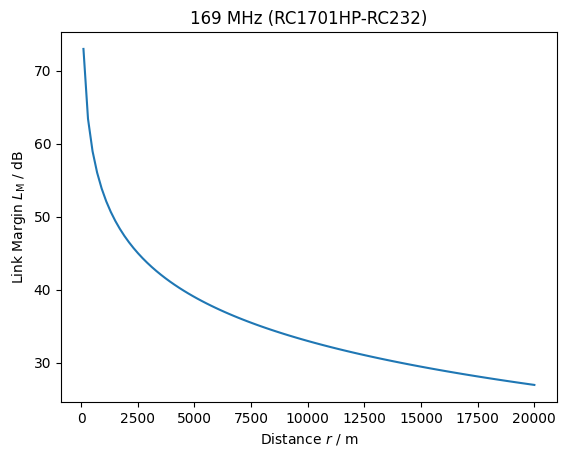

In [ ]:
f = 169.4625e+6                             # 169.4625 MHz radio frequency

P_TX = 27                                   # Transmit signal strength RC1701HP-RC232
G_TX = -5                                   # Dipole-antenna gain (estimated for suboptimal radiation angle, in reality dependant on the actual angle)
L_TX = 3                                    # Transmit (cable, ...) losses (estimation)

P_RX = -114                                 # Minimum receive signal strength RC1701HP-RC232, alternative: P_RX = -118
G_RX = 0                                    # Dipole antenna gain (estimated for optimal radiation angle)
L_RX = 3                                    # Receive (cable, ...) losses (estimation)

r = np.linspace(1e+2, 20e+3, 100)           # Distances (x-Axis)
L_M = LinkMargin(f, r, P_TX, G_TX, L_TX, P_RX, G_RX, L_RX)

plt.plot(r, L_M)
plt.ylabel(r'Link Margin $L_\mathrm{M}$ / dB')
plt.xlabel(r'Distance $r$ / m')
plt.title(r'169 MHz (RC1701HP-RC232)')

### Possible improvements

- Qualified guesses or even measurements of $L_\mathrm{TX}$ and $L_\mathrm{RX}$
- Inclusion of the real (angle dependant) gains of the sending antennas $G_\mathrm{TX}$
- Inclusion of the real (angle depandant) gains of the receiving antennas $G_\mathrm{RX}$